# Notebook 03 — Clustering & Recommendation

**Objective:** Apply PCA + K-Means to the processed feature matrix to
discover natural groupings in professional profiles, evaluate cluster
quality, interpret what each cluster represents, and demonstrate
profile recommendations using cosine similarity.

**Inputs:**
- `data/processed/X_processed.npy` — feature matrix from notebook 02
- `data/raw/profiles.csv` — original profiles for display layer

**Outputs:**
- `data/processed/cluster_labels.npy` — cluster assignment per profile
- `outputs/plots/` — PCA variance, elbow, silhouette, t-SNE figures
- `outputs/clusters/` — one CSV summary per cluster

In [39]:
import os
import sys

NOTEBOOK_DIR = os.path.abspath("")
PROJECT_ROOT = os.path.dirname(NOTEBOOK_DIR)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print(f"Project root : {PROJECT_ROOT}")

Project root : c:\programmes\unsupervised-professional-matching


In [40]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import davies_bouldin_score, silhouette_score

from src.config import (
    RAW_DATA_PATH, PROCESSED_PATH, PLOTS_DIR,
    PCA_COMPONENTS, K_RANGE
)
from src.models.clustering import (
    run_kmeans_experiment,
    plot_elbow_and_silhouette,
    fit_final_kmeans,
    profile_clusters
)
from src.models.compatibility import recommend_profiles

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.bbox"] = "tight"
warnings.filterwarnings("ignore")
print("Imports complete")

Imports complete


In [41]:
X = np.load(PROCESSED_PATH)
print(f"Feature matrix shape : {X.shape}")

df_original = pd.read_csv(RAW_DATA_PATH)
print(f"Profiles loaded      : {len(df_original):,}")

vocab_path = os.path.join(PROJECT_ROOT, "data", "processed", "skill_vocab.txt")
with open(vocab_path) as f:
    skill_vocab = [line.strip() for line in f.readlines()]
print(f"Skill vocabulary     : {len(skill_vocab)} terms")

Feature matrix shape : (50000, 188)
Profiles loaded      : 50,000
Skill vocabulary     : 100 terms


## 1. Dimensionality Reduction — PCA

The feature matrix has ~200 dimensions. K-Means degrades in high
dimensions because distances become increasingly uniform (curse of
dimensionality). We apply StandardScaler to normalize all features
before PCA, then reduce to a fixed number of components that capture
the most important variance while avoiding overfitting.

t-SNE will be used separately for 2D visualisation only —
clustering is always performed on PCA output, never on t-SNE output.
t-SNE distorts global structure and is not suitable as a clustering input.

In [42]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=PCA_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print(f"Original dimensions  : {X.shape[1]}")
print(f"PCA dimensions       : {X_pca.shape[1]}")
print(f"Variance retained    : {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"Compression ratio    : {X.shape[1]/X_pca.shape[1]:.1f}x")
print(f"\nPer-component variance:")
for i in range(len(pca.explained_variance_ratio_)):
    print(f"  PC{i+1:2d}: {pca.explained_variance_ratio_[i]*100:.2f}%")

Original dimensions  : 188
PCA dimensions       : 30
Variance retained    : 31.66%
Compression ratio    : 6.3x

Per-component variance:
  PC 1: 1.98%
  PC 2: 1.37%
  PC 3: 1.34%
  PC 4: 1.20%
  PC 5: 1.17%
  PC 6: 1.15%
  PC 7: 1.15%
  PC 8: 1.13%
  PC 9: 1.12%
  PC10: 1.12%
  PC11: 1.10%
  PC12: 1.10%
  PC13: 1.07%
  PC14: 1.06%
  PC15: 1.04%
  PC16: 1.04%
  PC17: 1.02%
  PC18: 1.01%
  PC19: 0.99%
  PC20: 0.98%
  PC21: 0.98%
  PC22: 0.96%
  PC23: 0.95%
  PC24: 0.93%
  PC25: 0.91%
  PC26: 0.89%
  PC27: 0.86%
  PC28: 0.83%
  PC29: 0.61%
  PC30: 0.60%


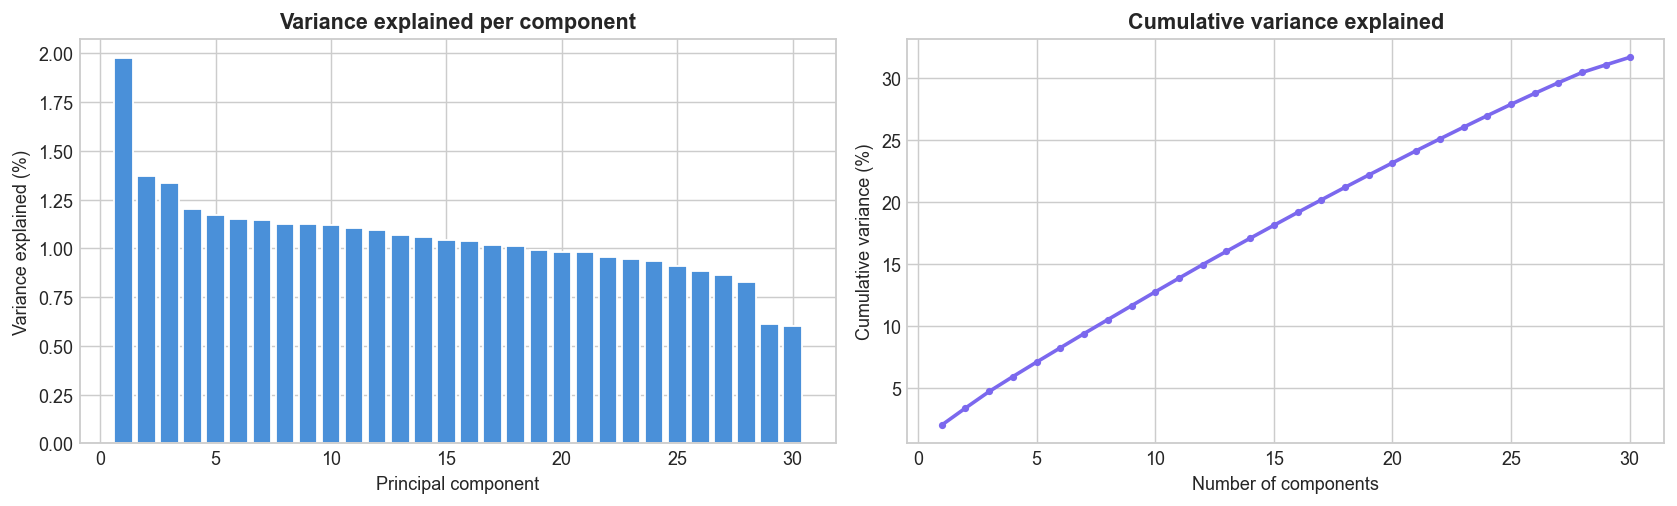

In [43]:
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, len(pca.explained_variance_ratio_) + 1),
            pca.explained_variance_ratio_ * 100,
            color="#4A90D9", edgecolor="white")
axes[0].set_title("Variance explained per component",
                  fontsize=12, fontweight="bold")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Variance explained (%)")

axes[1].plot(range(1, len(cumulative_variance) + 1),
             cumulative_variance * 100,
             marker=".", color="#7B68EE", linewidth=2)
axes[1].set_title("Cumulative variance explained",
                  fontsize=12, fontweight="bold")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative variance (%)")

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "09_pca_explained_variance.png"))
plt.show()

## 2. Choosing K — Elbow Method + Silhouette Score

Two complementary metrics are used to select K:

- **Inertia (elbow curve):** sum of squared distances from each point
  to its cluster centre. Lower is better, but always decreases with K.
  The "elbow" — where the rate of improvement slows — suggests a good K.

- **Silhouette score:** measures how similar a profile is to its own
  cluster versus neighbouring clusters. Ranges from -1 to 1.
  Higher is better. The peak identifies the most well-separated K.

Using both together avoids the weakness of either metric alone.

Running K-Means for K = 2 to 30...
  K= 2 | inertia=2,846,247 | silhouette=0.0459
  K= 3 | inertia=2,762,514 | silhouette=0.0492
  K= 4 | inertia=2,688,252 | silhouette=0.0502
  K= 5 | inertia=2,613,779 | silhouette=0.0571
  K= 6 | inertia=2,541,138 | silhouette=0.0618
  K= 7 | inertia=2,480,004 | silhouette=0.0698
  K= 8 | inertia=2,403,068 | silhouette=0.0764
  K= 9 | inertia=2,331,753 | silhouette=0.0918
  K=10 | inertia=2,263,120 | silhouette=0.1027
  K=11 | inertia=2,195,768 | silhouette=0.1091
  K=12 | inertia=2,128,544 | silhouette=0.1197
  K=13 | inertia=2,051,739 | silhouette=0.1300
  K=14 | inertia=1,983,914 | silhouette=0.1407
  K=15 | inertia=1,923,626 | silhouette=0.1494
  K=16 | inertia=1,906,111 | silhouette=0.1371
  K=17 | inertia=1,891,264 | silhouette=0.1265
  K=18 | inertia=1,878,360 | silhouette=0.1152
  K=19 | inertia=1,870,744 | silhouette=0.0940
  K=20 | inertia=1,860,811 | silhouette=0.0930
  K=21 | inertia=1,850,543 | silhouette=0.0867
  K=22 | inertia=1,843,11

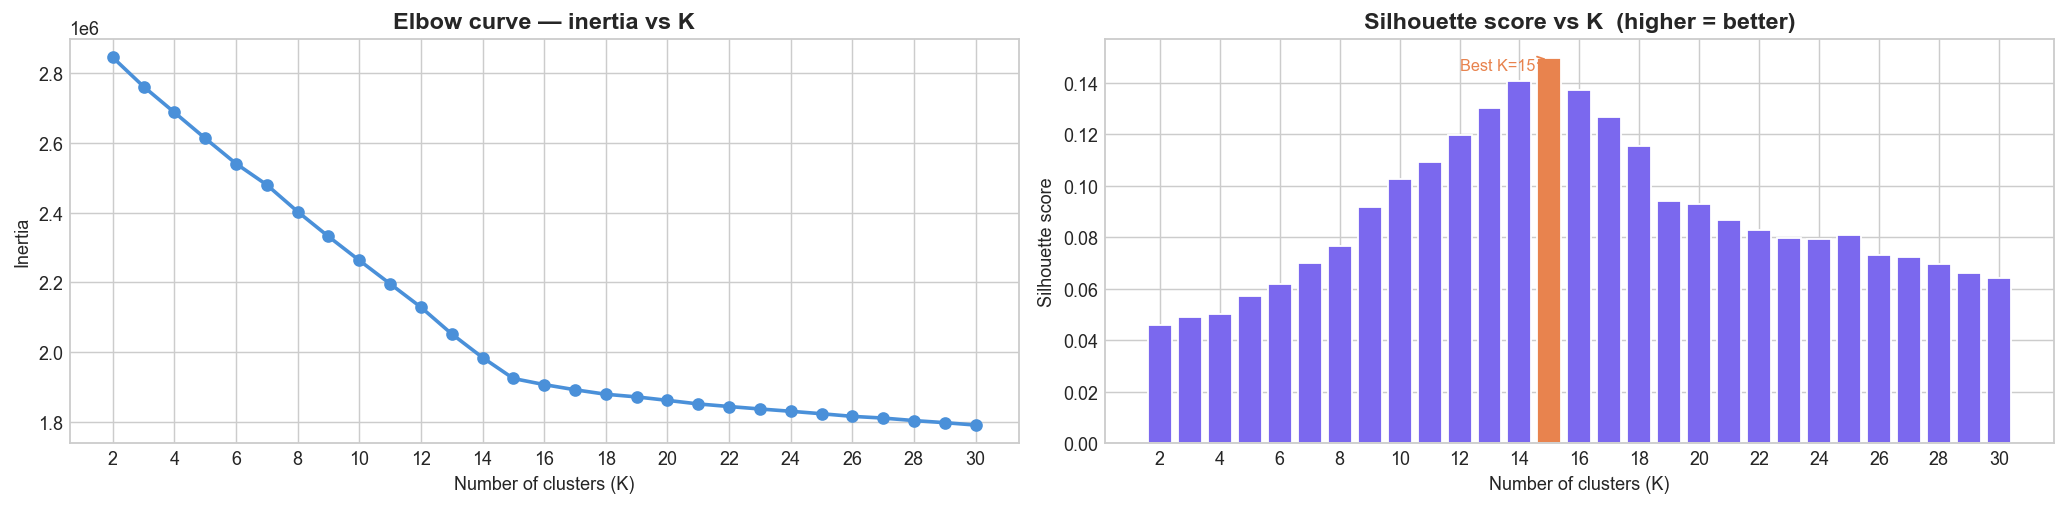


Best K by silhouette score: 15


In [44]:
results_df = run_kmeans_experiment(X_pca)
plot_elbow_and_silhouette(results_df)

In [45]:
BEST_K = int(results_df.loc[results_df["silhouette"].idxmax(), "k"])

print(f"Selected K : {BEST_K}")
print(f"\nFull results table:")
print(results_df.to_string(index=False))

Selected K : 15

Full results table:
 k     inertia  silhouette
 2 2846247.000    0.045872
 3 2762513.500    0.049216
 4 2688252.000    0.050194
 5 2613779.250    0.057087
 6 2541137.500    0.061798
 7 2480003.750    0.069841
 8 2403068.000    0.076449
 9 2331753.000    0.091820
10 2263120.000    0.102726
11 2195768.250    0.109123
12 2128544.500    0.119728
13 2051739.375    0.129953
14 1983913.750    0.140701
15 1923625.500    0.149415
16 1906110.625    0.137097
17 1891264.375    0.126535
18 1878359.500    0.115198
19 1870744.500    0.094048
20 1860810.875    0.092978
21 1850543.250    0.086698
22 1843117.125    0.082806
23 1836063.125    0.079730
24 1829425.125    0.079384
25 1822374.500    0.080877
26 1814831.000    0.073290
27 1809926.125    0.072387
28 1802690.125    0.069562
29 1796739.250    0.066207
30 1789796.875    0.064107


## 3. Fit Final Model

In [46]:
labels = fit_final_kmeans(X_pca, BEST_K)

df_original["cluster"] = labels

labels_path = os.path.join(PROJECT_ROOT, "data", "processed",
                           "cluster_labels.npy")
np.save(labels_path, labels)
print(f"Cluster labels saved")

✓ Final K-Means fitted  (K=15)
  Cluster sizes:
    Cluster 0: 3,322 profiles (6.6%)
    Cluster 1: 3,270 profiles (6.5%)
    Cluster 2: 3,355 profiles (6.7%)
    Cluster 3: 3,366 profiles (6.7%)
    Cluster 4: 3,333 profiles (6.7%)
    Cluster 5: 3,243 profiles (6.5%)
    Cluster 6: 3,355 profiles (6.7%)
    Cluster 7: 3,387 profiles (6.8%)
    Cluster 8: 3,242 profiles (6.5%)
    Cluster 9: 3,341 profiles (6.7%)
    Cluster 10: 3,318 profiles (6.6%)
    Cluster 11: 3,415 profiles (6.8%)
    Cluster 12: 3,296 profiles (6.6%)
    Cluster 13: 3,449 profiles (6.9%)
    Cluster 14: 3,308 profiles (6.6%)
Cluster labels saved


In [47]:
sil_score = silhouette_score(X_pca, labels, sample_size=5000,
                             random_state=42)
db_score  = davies_bouldin_score(X_pca, labels)

print("=" * 40)
print("Final model evaluation")
print("=" * 40)
print(f"K (clusters)           : {BEST_K}")
print(f"Silhouette score       : {sil_score:.4f}  (higher better, max 1.0)")
print(f"Davies-Bouldin index   : {db_score:.4f}  (lower better, min 0.0)")
print("=" * 40)

Final model evaluation
K (clusters)           : 15
Silhouette score       : 0.1494  (higher better, max 1.0)
Davies-Bouldin index   : 1.9500  (lower better, min 0.0)


## 4. Cluster Interpretation

For each cluster we compute the top skills, dominant industry, dominant
role, median experience, and seniority breakdown. This is what allows
clusters to be given human-readable names.

In [48]:
summary_df = profile_clusters(labels, df_original, skill_vocab)

print("Cluster summary:")
print(summary_df.to_string(index=False))

clusters_dir = os.path.join(PROJECT_ROOT, "outputs", "clusters")
for cluster_id in sorted(df_original["cluster"].unique()):
    subset = df_original[df_original["cluster"] == cluster_id]
    out_path = os.path.join(clusters_dir,
                            f"cluster_{cluster_id}_profiles.csv")
    subset.to_csv(out_path, index=False)

print(f"\nCluster CSVs saved")

Cluster summary:
 cluster  size  pct_of_total                                                                top_skills  dominant_industry        dominant_role  median_exp top_seniority
       0  3322           6.6          vba, risk assessment, excel, claims analysis, financial modeling          Insurance      Product Manager         5.4           mid
       1  3270           6.5    spss, laboratory techniques, genomics, clinical trials, bioinformatics      Biotechnology  Engineering Manager         5.4           mid
       2  3355           6.7 business analysis, stakeholder management, project management, aws, excel         Consulting    Software Engineer         5.1           mid
       3  3366           6.7                 data visualization, healthcare analytics, r, python, spss         Healthcare         Scrum Master         5.4           mid
       4  3333           6.7                                     kubernetes, git, sql, tensorflow, aws         Technology        Data Engi

## 5. t-SNE Visualisation

t-SNE projects the high-dimensional PCA space down to 2D for visual
inspection. Profiles that are close together in 2D were also close in
the original feature space.

Important: t-SNE is used for visualisation only. Clustering was
performed on PCA output.

Running t-SNE — this takes 2-4 minutes on 50k profiles...
[t-SNE] Computing 121 nearest neighbors...
[t-SNE] Indexed 50000 samples in 0.001s...
[t-SNE] Computed neighbors for 50000 samples in 2.017s...
[t-SNE] Computed conditional probabilities for sample 1000 / 50000
[t-SNE] Computed conditional probabilities for sample 2000 / 50000
[t-SNE] Computed conditional probabilities for sample 3000 / 50000
[t-SNE] Computed conditional probabilities for sample 4000 / 50000
[t-SNE] Computed conditional probabilities for sample 5000 / 50000
[t-SNE] Computed conditional probabilities for sample 6000 / 50000
[t-SNE] Computed conditional probabilities for sample 7000 / 50000
[t-SNE] Computed conditional probabilities for sample 8000 / 50000
[t-SNE] Computed conditional probabilities for sample 9000 / 50000
[t-SNE] Computed conditional probabilities for sample 10000 / 50000
[t-SNE] Computed conditional probabilities for sample 11000 / 50000
[t-SNE] Computed conditional probabilities for sample 12000

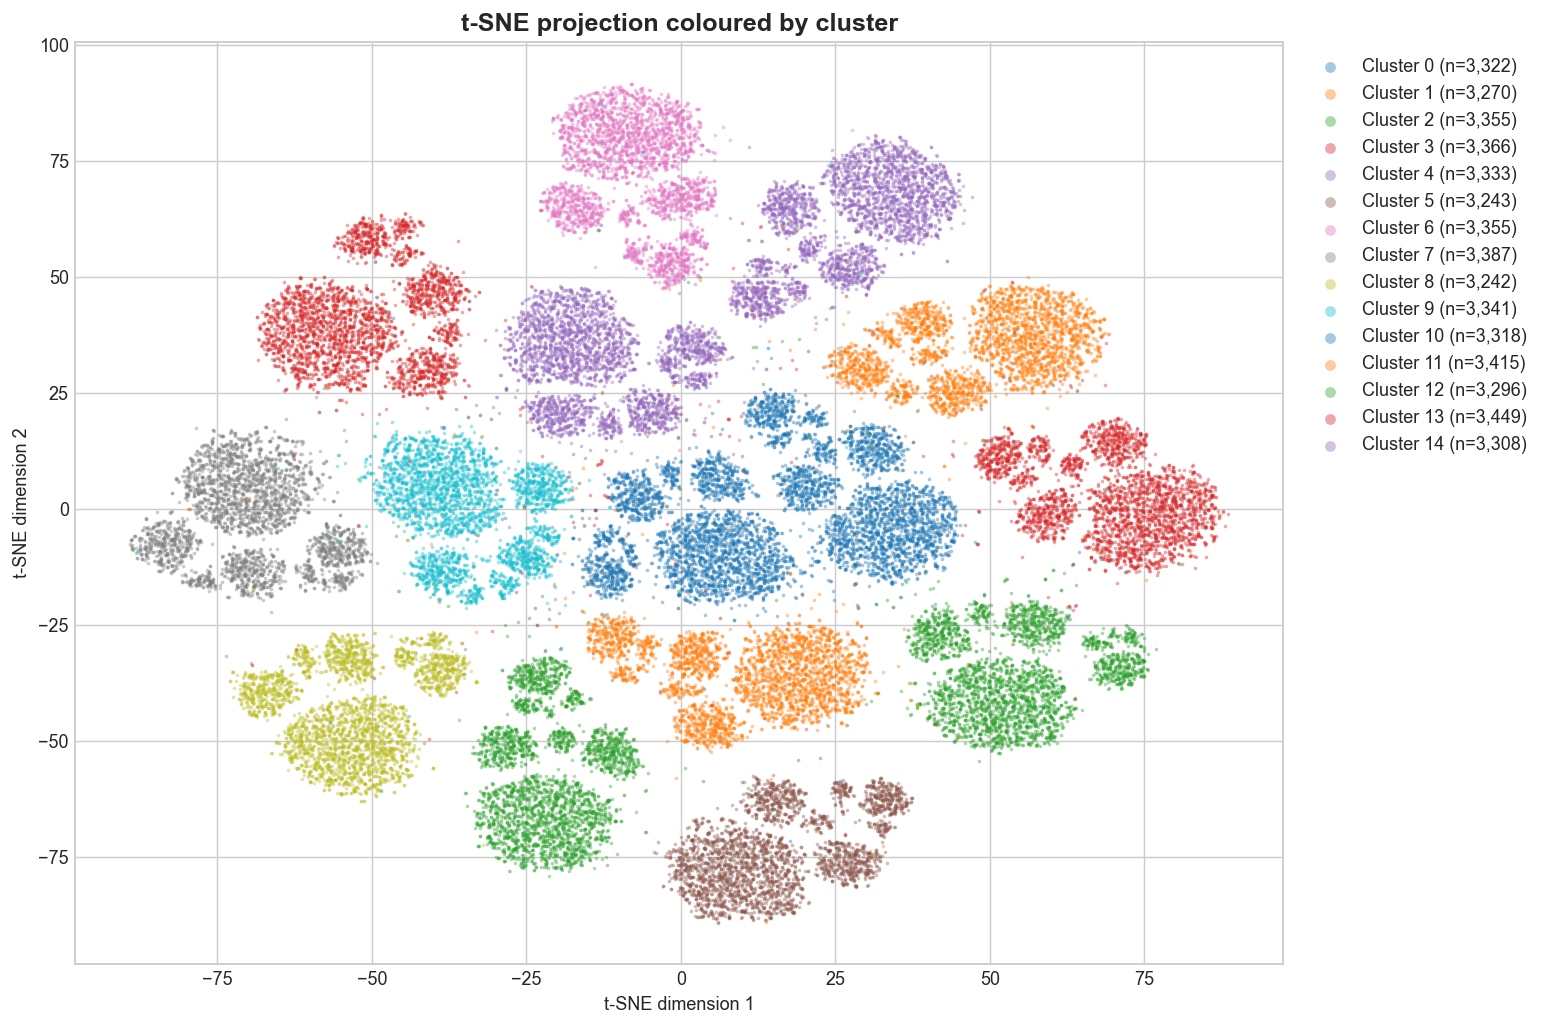

In [49]:
print("Running t-SNE — this takes 2-4 minutes on 50k profiles...")

tsne = TSNE(n_components=2, random_state=42, perplexity=40,
            max_iter=1000, verbose=1)
X_tsne = tsne.fit_transform(X_pca)

palette = sns.color_palette("tab10", n_colors=BEST_K)

fig, ax = plt.subplots(figsize=(12, 8))

for cluster_id in range(BEST_K):
    mask = labels == cluster_id
    ax.scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=[palette[cluster_id]],
        label=f"Cluster {cluster_id} (n={mask.sum():,})",
        alpha=0.4, s=4, linewidths=0
    )

ax.set_title("t-SNE projection coloured by cluster",
             fontsize=14, fontweight="bold")
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.legend(markerscale=3, bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, "10_tsne_clusters.png"))
plt.show()

## 6. Recommendation Demo

In [50]:
QUERY_IDX = 0

query = df_original.iloc[QUERY_IDX]
print("=" * 55)
print("QUERY PROFILE")
print("=" * 55)
print(f"Name            : {query['name']}")
print(f"Role            : {query['current_role']}")
print(f"Company         : {query['current_company']}")
print(f"Industry        : {query['industry']}")
print(f"Seniority       : {query['seniority_level']}")
print(f"Experience      : {query['years_experience']} years")
print(f"Location        : {query['location']}")
print(f"Remote pref     : {query['remote_preference']}")
print(f"Skills          : {query['skills']}")
print(f"Goals           : {query['goals']}")
print(f"Needs           : {query['needs']}")
print(f"Can offer       : {query['can_offer']}")
print(f"Cluster         : {query['cluster']}")

QUERY PROFILE
Name            : Thomas Johnson
Role            : Data Engineer
Company         : Meta
Industry        : Energy
Seniority       : senior
Experience      : 11.3 years
Location        : San Antonio, Germany
Remote pref     : onsite
Skills          : ['python', 'plc', 'machine learning', 'c++', 'automation', 'quantitative analysis', 'matlab', 'scada', 'power systems', 'lean manufacturing']
Goals           : ['leadership']
Needs           : ['research opportunities']
Can offer       : ['research expertise']
Cluster         : 9


In [51]:
recommendations = recommend_profiles(
    query_idx   = QUERY_IDX,
    X           = X,
    labels      = labels,
    df_original = df_original,
    top_n       = 5
)

print("=" * 55)
print(f"TOP 5 SIMILAR PROFILES  (Cluster {labels[QUERY_IDX]})")
print("=" * 55)

for rank, (_, row) in enumerate(recommendations.iterrows(), start=1):
    print(f"\nRank {rank}  —  similarity: {row['similarity_score']:.4f}")
    print(f"  Name        : {row['name']}")
    print(f"  Role        : {row['current_role']}")
    print(f"  Company     : {row['current_company']}")
    print(f"  Industry    : {row['industry']}")
    print(f"  Seniority   : {row['seniority_level']}")
    print(f"  Experience  : {row['years_experience']} years")
    print(f"  Location    : {row['location']}")
    print(f"  Skills      : {row['skills']}")
    print(f"  Goals       : {row['goals']}")
    print(f"  Needs       : {row['needs']}")
    print(f"  Can offer   : {row['can_offer']}")
    print("-" * 55)

TOP 5 SIMILAR PROFILES  (Cluster 9)

Rank 1  —  similarity: 0.6119
  Name        : Ashley Martin
  Role        : ML Engineer
  Company     : Deloitte
  Industry    : Energy
  Seniority   : executive
  Experience  : 18.6 years
  Location    : Jacksonville, OR
  Skills      : ['cloud', 'python', 'plc', 'scada', 'lean manufacturing', 'security', 'power systems', 'customer segmentation', 'statistics']
  Goals       : ['technical expertise']
  Needs       : ['peer feedback', 'career advice']
  Can offer   : ['career guidance']
-------------------------------------------------------

Rank 2  —  similarity: 0.6001
  Name        : Anthony Jones
  Role        : CTO
  Company     : Wells Fargo
  Industry    : Energy
  Seniority   : executive
  Experience  : 18.1 years
  Location    : New York, Canada
  Skills      : ['healthcare analytics', 'sas', 'power systems', 'quantitative analysis', 'scada', 'python', 'plc', 'statistics', 'aerodynamics']
  Goals       : ['industry insights']
  Needs       

## 7. Results Summary